# Citi Bike Rebalancing-02

This notebook uses the processed hourly data from `01_data_processing.ipynb` to train and evaluate tabular reinforcement learning agents.

The notebook has five main parts:

1. Load processed data and convert it into daily episode dictionaries.

2. Define the Citi Bike rebalancing environment.

3. Build two baseline agents: Do nothing baseline and Threshould baseline.

3. Build and train tabular RL agents: SARSA and Q-learning. Visualize training performance using TD error and episode reward.

4. Evaluate all agents(Do Nothing, Threshold Baseline, SARSA, and Q-learning) on test set. Then visualized the unmet demand and learned polices from SARSA and Q-learning.

The outputs of this notebook are:
- `results/tabular_summary.csv`
- `results/tabular_test_daily_unmet.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

SEED = 42
np.random.seed(SEED)
PROCESSED_DIR = Path("../data/processed")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


**Load hourly data and convert to dictionary form**

In [2]:
train_data = pd.read_csv(PROCESSED_DIR / "train_hourly.csv")
test_data = pd.read_csv(PROCESSED_DIR / "test_hourly.csv")
station_info = pd.read_csv(PROCESSED_DIR / "station_info.csv")
train_data["date"] = pd.to_datetime(train_data["date"])
test_data["date"] = pd.to_datetime(test_data["date"])

def to_daily_dict(df):
    """
    Convert hourly environment data into daily episode dictionaries.

    Each key is one date.
    Each value contains 24-hour departure and arrival arrays
    for the two selected stations.
    """

    daily = {}
    for date, day_df in df.groupby("date"):
        day_df = day_df.sort_values("hour").copy()
        daily[date] = { "departures": day_df[["d_s1", "d_s2"]].to_numpy(dtype=int),"arrivals": day_df[["r_s1", "r_s2"]].to_numpy(dtype=int)}
    return daily

train_daily = to_daily_dict(train_data)
test_daily = to_daily_dict(test_data)

print("Number of train episodes:", len(train_daily))
print("Number of test episodes:", len(test_daily))

Number of train episodes: 396
Number of test episodes: 28


## Environment Setup 

In [3]:
class CitiBikeEnv:
    """
    A two-station Citi Bike rebalancing environment.

    Environment rules:
        - One episode is one day, with 24 hourly steps.
        - At the beginning of each episode, both stations start with the
          same initial inventory.
        - The agent can move bikes between the two selected stations at the
          beginning of each hour.
        - No bikes are added from outside the system.

    State:
        (hour, b1, b2)

    Actions:
        0: do nothing
        1-20: move action bikes from station 1 to station 2
        21-40: move action - 20 bikes from station 2 to station 1

    Actual moved amount:
        moved_bikes = min(
            intended_amount,
            source_inventory,
            capacity - target_inventory
        )

    Reward:
        reward = - total unmet demand - operation_cost * move_action

    where:
        move_action = 1 if at least one bike is actually moved,
        move_action = 0 otherwise.
    """

    def __init__(self, capacity=20, init_inventory=10, operation_cost=0.1):
        self.capacity = capacity
        self.init_inventory = init_inventory
        self.operation_cost = operation_cost
        self.n_stations = 2
        self.n_hours = 24
        self.action_space = list(range(41))
        self.inventory = None
        self.hour = None
        self.departures = None
        self.arrivals = None

    def reset(self, day_data):
        """
        Reset the environment with one day's data.

        day_data should contain:
            {
                "departures": np.array of shape (24, 2),
                "arrivals": np.array of shape (24, 2)
            }

        Returns:
            initial state: (hour, b1, b2)
        """

        self.departures = day_data["departures"]
        self.arrivals = day_data["arrivals"]
        self.inventory = np.full(self.n_stations, self.init_inventory, dtype=int)
        self.hour = 0

        return self._state()

    def _state(self):
        """
        Return the current state as:(hour, b1, b2)
        """

        return (int(self.hour), int(self.inventory[0]),int(self.inventory[1]))

    def _decode_action(self, action):
        """
        Convert action number into source, target, and intended move amount.

        Returns:
            source, target, intended_amount

        Action meaning:
            0: do nothing
            1-20: station 1 -> station 2
            21-40: station 2 -> station 1
        """

        if action == 0:
            return None, None, 0

        if 1 <= action <= 20:
            source = 0
            target = 1
            intended_amount = action
        elif 21 <= action <= 40:
            source = 1
            target = 0
            intended_amount = action - 20

        return source, target, intended_amount

    def step(self, action):
        """
        Run one hourly step.

        Parameters
        ----------
        action : int
            0 = do nothing
            1-20 = move 1-20 bikes from station 1 to station 2
            21-40 = move 1-20 bikes from station 2 to station 1

        Returns
        -------
        next_state : tuple or None
            Next state after transition, or None if the episode is over.

        reward : float
            Negative unmet demand minus operation cost.

        done : bool
            Whether the daily episode is over.

        info : dict
            Extra diagnostic information for evaluation.
        """
        inventory = self.inventory.copy()

        # 1. Move bikes before serving departure demand
        source, target, intended_amount = self._decode_action(action)

        moved_bikes = 0

        if action != 0:
            moved_bikes = min(
                intended_amount,
                inventory[source],
                self.capacity - inventory[target]
            )

            inventory[source] -= moved_bikes
            inventory[target] += moved_bikes

        inventory_after_move = inventory.copy()

        # 2. Serve departures and calculate unmet demand
        dep = self.departures[self.hour]

        served = np.minimum(inventory_after_move, dep)
        unmet = np.maximum(0, dep - inventory_after_move)

        # 3. Add arrivals and update inventory
        arr = self.arrivals[self.hour]

        new_inventory = inventory_after_move - served + arr
        new_inventory = np.minimum(self.capacity, new_inventory)
        new_inventory = np.maximum(0, new_inventory)

        # 4. Reward
        total_unmet = int(unmet.sum())
        total_served = int(served.sum())
        move_action = int(moved_bikes > 0)

        reward = -total_unmet - self.operation_cost * move_action

        # 5. Enter next hour
        self.inventory = new_inventory.astype(int)
        self.hour += 1

        done = self.hour == self.n_hours
        if done:
            next_state = None
        else:
            next_state = self._state()

        info = {
            "served": total_served,
            "unmet": total_unmet,
            "moved_bikes": int(moved_bikes),
            "move_action": move_action,
            "inventory": self.inventory.copy()
        }

        return next_state, reward, done, info

## Baseline 

In [4]:
class DoNothingAgent:
    """
    Baseline agent that never moves bikes.
    """
    def greedy_action(self, obs):
        return 0

class ThresholdAgent:
    """
    Baseline agent that moves bikes from the station with more inventory
    to the station with lower inventory when the lower inventory is below
    a threshold.

    Actions:
        0: do nothing
        1-20: move 1-20 bikes from s1 to s2
        21-40: move 1-20 bikes from s2 to s1
    """

    def __init__(self, threshold=5, move_amount=5):
        self.threshold = threshold
        self.move_amount = move_amount

    def greedy_action(self, obs):
        hour, b1, b2 = obs

        if b1 < self.threshold and b2 > b1:
            return 20 + min(self.move_amount, 20)

        if b2 < self.threshold and b1 > b2:
            return min(self.move_amount, 20)

        return 0

## SARSA

### Define SARSA Agent

In [5]:
class SARSAAgent:
    """
    Tabular SARSA agent for the two-station Citi Bike rebalancing environment.

    The agent learns Q(s, a) using the on-policy SARSA update.
    During training, actions are selected using an epsilon-greedy policy.
    During evaluation, greedy_action() is used to select the best learned action.
    """

    def __init__(
        self,
        n_actions: int,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        self.n_actions = n_actions

        # For each state, store a Q-value array of length n_actions.
        # Example: q_values[(0, 10, 10)] = [Q(s,0), Q(s,1), ..., Q(s,40)]
        self.q_values = defaultdict(lambda: np.zeros(self.n_actions))

        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

    def get_action(self, obs: tuple) -> int:
        """
        Returns the highest q-value action with probability (1 - epsilon);
        otherwise returns a random action with probability epsilon to ensure exploration.

        Parameters:
        obs: current state (hour, b1, b2)

        Returns:
        action: selected action from {0, ..., 40}
        """

        # Explore: random action
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)

        # Exploit using current highest Q-value
        q_values = self.q_values[obs]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]

        return int(np.random.choice(best_actions))

    def greedy_action(self, obs: tuple) -> int:
        """
        Select the greedy action without epsilon exploration.
        This is used for test-set evaluation.
        """

        q_values = self.q_values[obs]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]

        return int(np.random.choice(best_actions))

    def update(
        self,
        obs: tuple,
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple,
        next_action: int
    ):
        """
        Update the Q-value for one action and record the TD error.

        SARSA update:
            Q(s,a) <- Q(s,a) + alpha * TD error

        where:
            TD error = r + gamma * Q(s', a') - Q(s, a)

        Unlike Q-learning, SARSA uses the next action actually selected
        by the current epsilon-greedy policy.

        Parameters:
        obs: current state (hour, b1, b2)
        action: action taken at state obs
        reward: reward received after taking the action
        terminated: whether the episode has ended after this step
        next_obs: next state after taking the action
        next_action: next action selected at next_obs
        """

        if terminated:
            future_q_value = 0
        else:
            future_q_value = self.q_values[next_obs][next_action]

        td_error = reward + self.discount_factor * future_q_value - self.q_values[obs][action]

        self.q_values[obs][action] += self.lr * td_error

        return abs(td_error)

    def decay_epsilon(self):
        """
        Decay epsilon after each episode to reduce exploration over time.
        """

        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

### Train SARSA Agent

In [6]:
def train_sarsa_agent(train_daily, agent, n_episodes,seed=SEED):
    """
    Train a SARSA agent on the training daily data.

    At the beginning of each episode, one training day is randomly sampled.
    The environment is reset using that day's departures and arrivals.
    Epsilon is decayed after each episode.

    Parameters:
    train_daily: dict
        Daily training data returned by make_daily_data().
        Each key is one date, and each value contains:
            - departures: numpy array of shape (24, 2)
            - arrivals: numpy array of shape (24, 2)

    agent: SARSAAgent
        SARSA agent with epsilon-greedy action selection.

    n_episodes: int
        Total number of training episodes to run.

    Returns:
    episode_rewards: list
        Total reward per episode.

    td_errors: list
        TD error recorded at each step during training.
    """
    np.random.seed(seed)
    env = CitiBikeEnv()
    train_days = list(train_daily.keys())

    episode_rewards = []
    episode_unmet = []
    td_errors = []

    for episode in range(n_episodes):
        # Randomly sample one training day as one episode
        day = np.random.choice(train_days)
        obs = env.reset(train_daily[day])
        action = agent.get_action(obs)

        # Initialize episode-level metrics
        terminated = False
        total_reward = 0
        total_unmet = 0
        
        while not terminated:
            # Take action in the environment
            next_obs, reward, terminated, info = env.step(action)
            total_reward += reward
            total_unmet += info["unmet"]

            # Select next action using the same epsilon-greedy policy
            if terminated:
                next_action = None
            else:
                next_action = agent.get_action(next_obs)

            # Update SARSA Q-values
            td_error = agent.update(
                obs=obs,
                action=action,
                reward=reward,
                terminated=terminated,
                next_obs=next_obs,
                next_action=next_action
            )

            td_errors.append(td_error)

            # Move to the next state-action pair
            obs = next_obs
            action = next_action

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_unmet.append(total_unmet)

    return episode_rewards, td_errors, episode_unmet

In [ ]:
sarsa_agent = SARSAAgent(
    n_actions=41,
    learning_rate=0.1,
    initial_epsilon=1.0,
    epsilon_decay=1.0 / 100000,
    final_epsilon=0.05,
    discount_factor=0.95)

sarsa_episode_rewards, sarsa_td_errors, sarsa_episode_unmet = train_sarsa_agent(
    train_daily=train_daily,
    agent=sarsa_agent,
    n_episodes=100000,
    seed=SEED)

### Visualize SARSA Training Performance

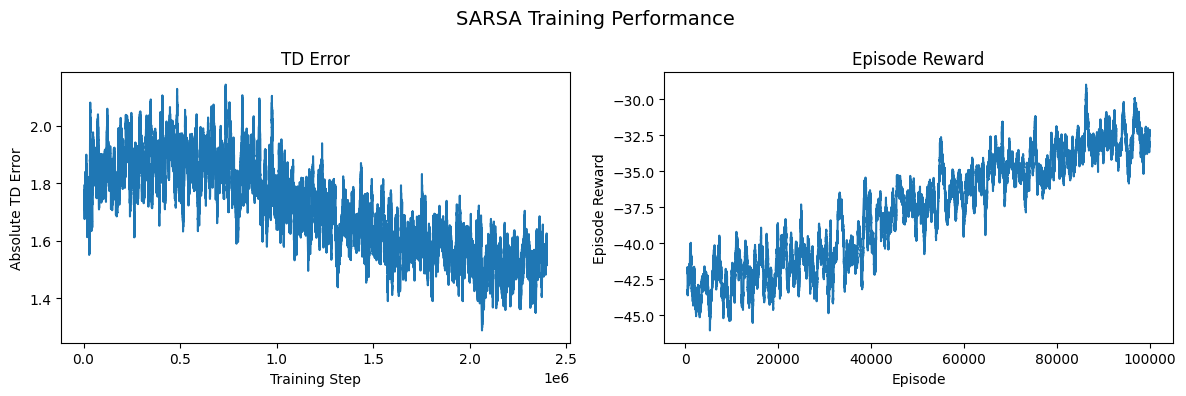

In [14]:
sarsa_reward_ma = pd.Series(sarsa_episode_rewards).rolling(500).mean()
sarsa_td_ma = pd.Series(sarsa_td_errors).rolling(5000).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("SARSA Training Performance", fontsize=14)
axes[0].plot(sarsa_td_ma)
axes[0].set_title("TD Error")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Absolute TD Error")
axes[1].plot(sarsa_reward_ma)
axes[1].set_title("Episode Reward")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Episode Reward")
plt.tight_layout()
plt.show()

## Q-learning
### Define Q-learning Agent

In [9]:
class QLearningAgent:
    """
    Tabular Q-learning agent for the two-station Citi Bike rebalancing environment.

    The agent learns Q(s, a) using the off-policy Q-learning update.
    During training, actions are selected using an epsilon-greedy policy.
    During evaluation, greedy_action() is used to select the best learned action.
    """
    
    def __init__(
        self,
        n_actions: int,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
    ):
        self.n_actions = n_actions

        # For each state, store a Q-value array of length n_actions.
        # Example: q_values[(0, 10, 10)] = [Q(s,0), Q(s,1), ..., Q(s,40)]
        self.q_values = defaultdict(lambda: np.zeros(self.n_actions))

        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

    def get_action(self, obs: tuple) -> int:
        """
        Returns the highest q-value action with probability (1 - epsilon);
        otherwise returns a random action with probability epsilon to ensure exploration.

        Parameters:
        obs: current state (hour, b1, b2)

        Returns:
        action: selected action from {0, ..., 40}
        """

        # Explore: random action
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.n_actions)

        # Exploit with random tie-breaking
        q_values = self.q_values[obs]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]

        return int(np.random.choice(best_actions))

    def greedy_action(self, obs: tuple) -> int:
        """
        Select the greedy action without epsilon exploration.
        This is used for test-set evaluation.
        """

        q_values = self.q_values[obs]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]

        return int(np.random.choice(best_actions))

    def update(self, obs: tuple, action: int, reward: float, terminated: bool, next_obs: tuple):
        """
        Update the Q-value for one action and record the TD error.

        Q-learning update:
            Q(s,a) <- Q(s,a) + alpha * TD error

        where:
            TD error = r + gamma * max_a' Q(s', a') - Q(s, a)

        Parameters:
        obs: current state (hour, b1, b2)
        action: action taken at state obs
        reward: reward received after taking the action
        terminated: whether the episode has ended after this step
        next_obs: next state after taking the action
        """

        if terminated:
            future_q_value = 0
        else:
            future_q_value = np.max(self.q_values[next_obs])

        td_error = reward + self.discount_factor * future_q_value - self.q_values[obs][action]

        self.q_values[obs][action] += self.lr * td_error

        return abs(td_error)

    def decay_epsilon(self):
        """
        Decay epsilon after each episode to reduce exploration over time.
        """

        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

### Train Q-learning Agent

In [10]:
def train_q_learning_agent(train_daily, agent, n_episodes, seed=SEED):
    """
    Train a Q-learning agent on the training daily data.

    At the beginning of each episode, one training day is randomly sampled.
    The environment is reset using that day's departures and arrivals.
    Q-values are updated after each step, and epsilon is decayed after each episode.

    Parameters:
    train_daily: dict
        Daily training data returned by make_daily_data().
        Each key is one date, and each value contains:
            - departures: numpy array of shape (24, 2)
            - arrivals: numpy array of shape (24, 2)

    agent: QLearningAgent
        Q-learning agent with epsilon-greedy action selection.

    n_episodes: int
        Total number of training episodes to run.

    seed: int
        Random seed for reproducibility.

    Returns:
    episode_rewards: list
        Total reward per episode.

    episode_unmet: list
        Total unmet demand per episode.

    td_errors: list
        Absolute TD error per update.
    """

    np.random.seed(seed)

    env = CitiBikeEnv()
    train_days = list(train_daily.keys())

    episode_rewards = []
    episode_unmet = []
    td_errors = []

    for episode in range(n_episodes):
        # Randomly sample one training day as one episode
        day = np.random.choice(train_days)
        obs = env.reset(train_daily[day])

        # Initialize episode-level metrics
        terminated = False
        total_reward = 0
        total_unmet = 0

        while not terminated:
            # Choose action using epsilon-greedy policy
            action = agent.get_action(obs)

            # Take action in the environment
            next_obs, reward, terminated, info = env.step(action)

            # Update Q-value using the Q-learning target
            td_error = agent.update(
                obs=obs,
                action=action,
                reward=reward,
                terminated=terminated,
                next_obs=next_obs
            )

            td_errors.append(td_error)

            # Record episode-level metrics
            total_reward += reward
            total_unmet += info["unmet"]

            # Move to next state
            obs = next_obs

        # Decay epsilon after each episode
        agent.decay_epsilon()

        episode_rewards.append(total_reward)
        episode_unmet.append(total_unmet)

    return episode_rewards, td_errors, episode_unmet

In [11]:
q_agent = QLearningAgent(
    n_actions=41,
    learning_rate=0.1,
    initial_epsilon=1.0,
    epsilon_decay=1.0 / 100000,
    final_epsilon=0.05,
    discount_factor=0.95)

q_episode_rewards, q_td_errors, q_episode_unmet = train_q_learning_agent(
    train_daily=train_daily,
    agent=q_agent,
    n_episodes=100000,
    seed=SEED)

### Visualize Q-learning Training Performance

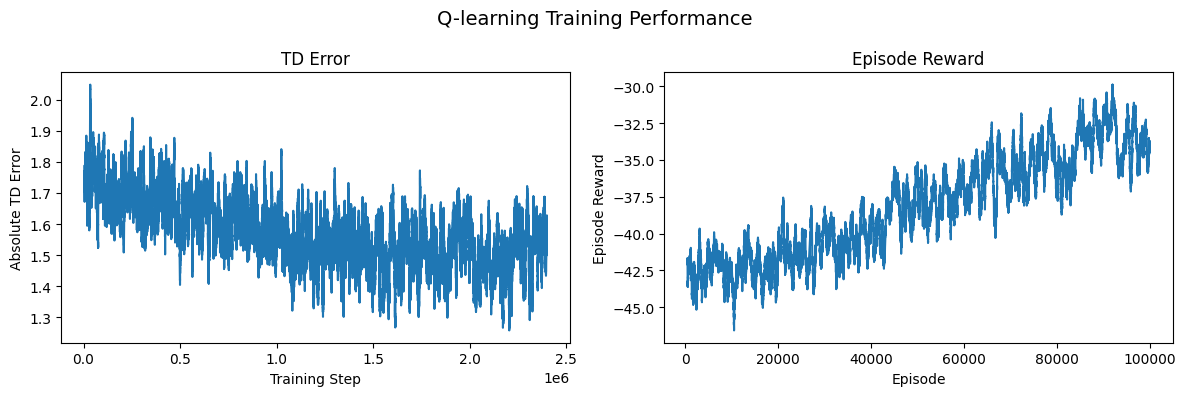

In [13]:
q_reward_ma = pd.Series(q_episode_rewards).rolling(500).mean()
q_td_ma = pd.Series(q_td_errors).rolling(5000).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Q-learning Training Performance", fontsize=14)
axes[0].plot(q_td_ma)
axes[0].set_title("TD Error")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Absolute TD Error")
axes[1].plot(q_reward_ma)
axes[1].set_title("Episode Reward")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Episode Reward")
plt.tight_layout()
plt.show()

## Evaluation Results

In [15]:
def evaluate_agent(test_daily, agent, seed=SEED):
    """
    Evaluate a trained agent on test daily data.

    Parameters
    ----------
    test_daily : dict
        Daily test data. Each key is one date, and each value contains
        24-hour departures and arrivals.

    agent : object
        Trained agent with a greedy_action(obs) method.

    Returns
    -------
    results_df : pd.DataFrame
        Daily evaluation results.
    """

    np.random.seed(seed)
    env = CitiBikeEnv()
    results = []

    for date, day_data in test_daily.items():
        obs = env.reset(day_data)
        done = False
        total_reward = 0
        total_unmet = 0
        total_served = 0
        total_moved_bikes = 0
        total_move_actions = 0

        while not done:
            action = agent.greedy_action(obs)
            next_obs, reward, done, info = env.step(action)
            total_reward += reward
            total_unmet += info["unmet"]
            total_served += info["served"]
            total_moved_bikes += info["moved_bikes"]
            total_move_actions += info["move_action"]
            obs = next_obs

        results.append({
            "date": date,
            "total_reward": total_reward,
            "total_unmet": total_unmet,
            "total_served": total_served,
            "total_moved_bikes": total_moved_bikes,
            "total_move_actions": total_move_actions})

    results_df = pd.DataFrame(results)

    summary = {
        "avg_daily_reward": results_df["total_reward"].mean(),
        "avg_daily_unmet": results_df["total_unmet"].mean(),
        "avg_daily_served": results_df["total_served"].mean(),
        "avg_daily_moved_bikes": results_df["total_moved_bikes"].mean(),
        "avg_daily_move_actions": results_df["total_move_actions"].mean()
    }

    return summary, results_df

**Evaluate all agents**

In [16]:
do_nothing_agent = DoNothingAgent()
threshold_agent = ThresholdAgent(threshold=5, move_amount=5)

do_nothing_summary, do_nothing_test_results = evaluate_agent(test_daily=test_daily,agent=do_nothing_agent)
threshold_summary, threshold_test_results = evaluate_agent(test_daily=test_daily,agent=threshold_agent)
sarsa_summary, sarsa_test_results = evaluate_agent(test_daily=test_daily,agent=sarsa_agent)
q_summary, q_test_results = evaluate_agent(test_daily=test_daily, agent=q_agent)

#### Result Summary

In [17]:
test_summary_df = pd.DataFrame([
    {"model": "Do Nothing", **do_nothing_summary},
    {"model": "Threshold Baseline", **threshold_summary},
    {"model": "SARSA", **sarsa_summary},
    {"model": "Q-learning", **q_summary}])

test_summary_df

,model,avg_daily_reward,avg_daily_unmet,avg_daily_served,avg_daily_moved_bikes,avg_daily_move_actions
0,Do Nothing,-7.428571,7.428571,44.500000,0.000000,0.000000
1,Threshold Baseline,-6.810714,6.500000,45.428571,14.892857,3.107143
2,SARSA,-7.253571,5.678571,46.250000,83.857143,15.750000
3,Q-learning,-6.003571,4.642857,47.285714,77.250000,13.607143


In [18]:
test_summary_df.to_csv(RESULTS_DIR / "tabular_summary.csv", index=False)

### Visualize Daily Unmet Demand on the Test Set
The learned RL policies generally reduce unmet demand compared with the do-nothing baseline, especially on high-demand days. Q-learning performs slightly better than SARSA on several peak-demand dates.

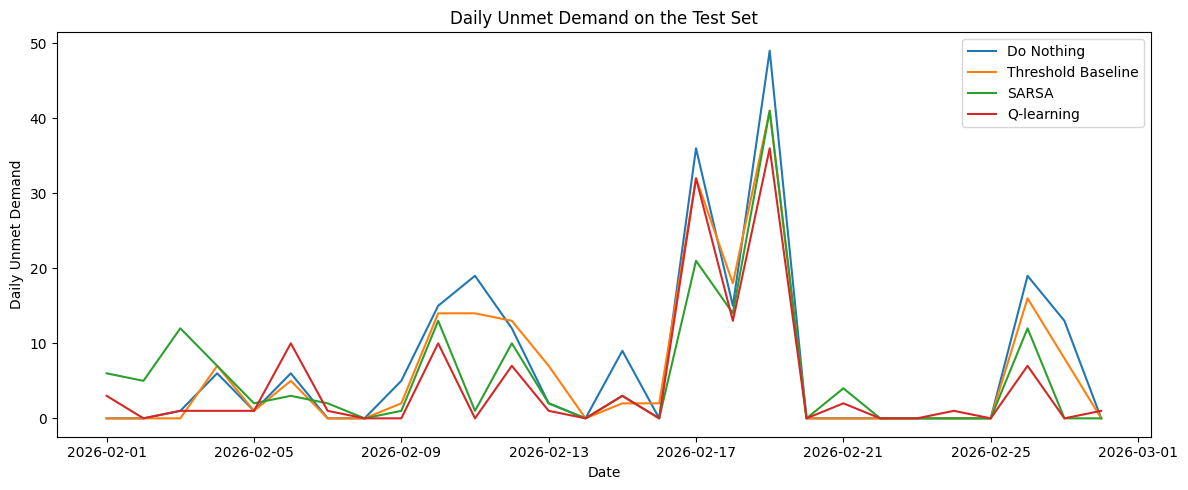

In [20]:
test_unmet_df = pd.DataFrame({
    "date": do_nothing_test_results["date"],
    "Do Nothing": do_nothing_test_results["total_unmet"].values,
    "Threshold Baseline": threshold_test_results["total_unmet"].values,
    "SARSA": sarsa_test_results["total_unmet"].values,
    "Q-learning": q_test_results["total_unmet"].values})

plt.figure(figsize=(12, 5))
plt.plot(test_unmet_df["date"], test_unmet_df["Do Nothing"], label="Do Nothing")
plt.plot(test_unmet_df["date"], test_unmet_df["Threshold Baseline"], label="Threshold Baseline")
plt.plot(test_unmet_df["date"], test_unmet_df["SARSA"], label="SARSA")
plt.plot(test_unmet_df["date"], test_unmet_df["Q-learning"], label="Q-learning")
plt.title("Daily Unmet Demand on the Test Set")
plt.xlabel("Date")
plt.ylabel("Daily Unmet Demand")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
test_unmet_df.to_csv(RESULTS_DIR / "tabular_test_daily_unmet.csv", index=False)

### Visualize Learned Policies
The policy heatmaps show how SARSA and Q-learning choose different rebalancing directions under different inventory states and hours. At hour 18, both methods learn more blue actions, meaning they often move bikes from Oakland Ave to Grove St PATH, which matches the evening demand pattern at Grove St PATH. Q-learning appears slightly more structured, while SARSA is more conservative and scattered.

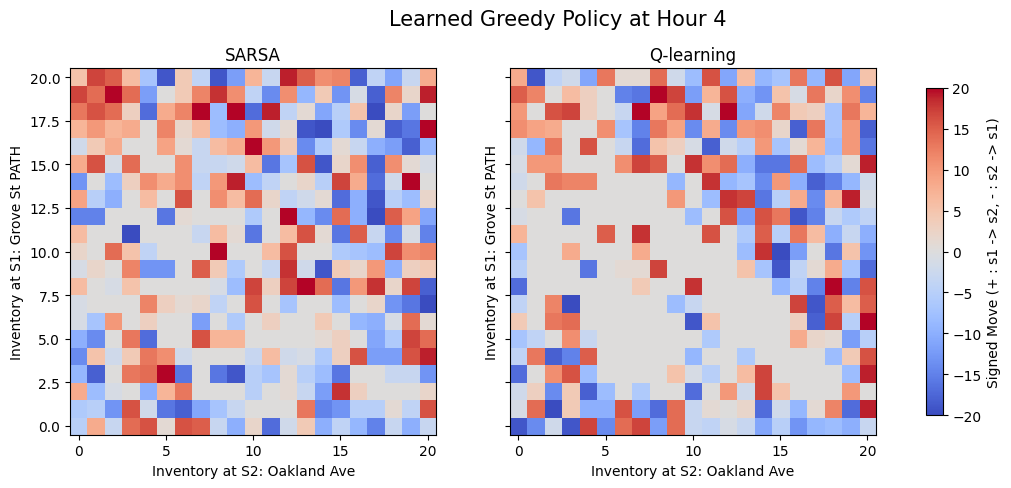

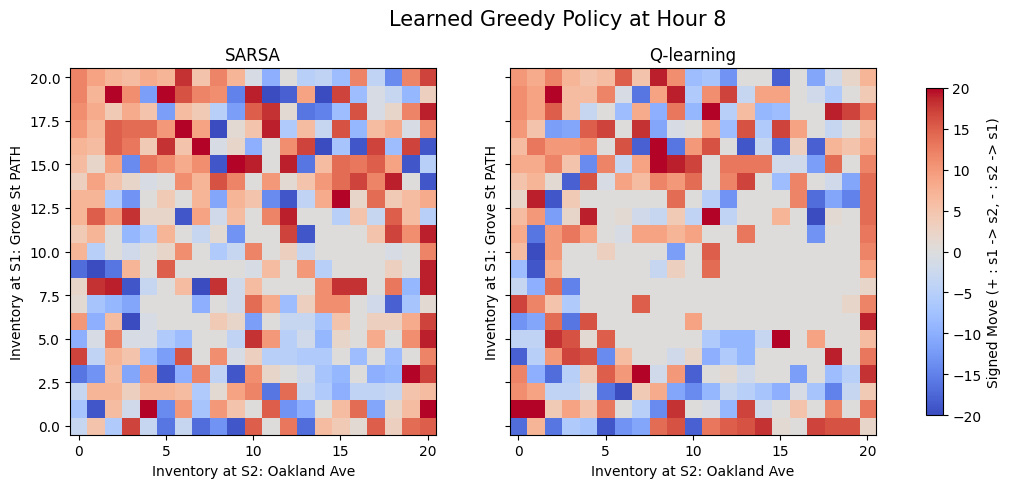

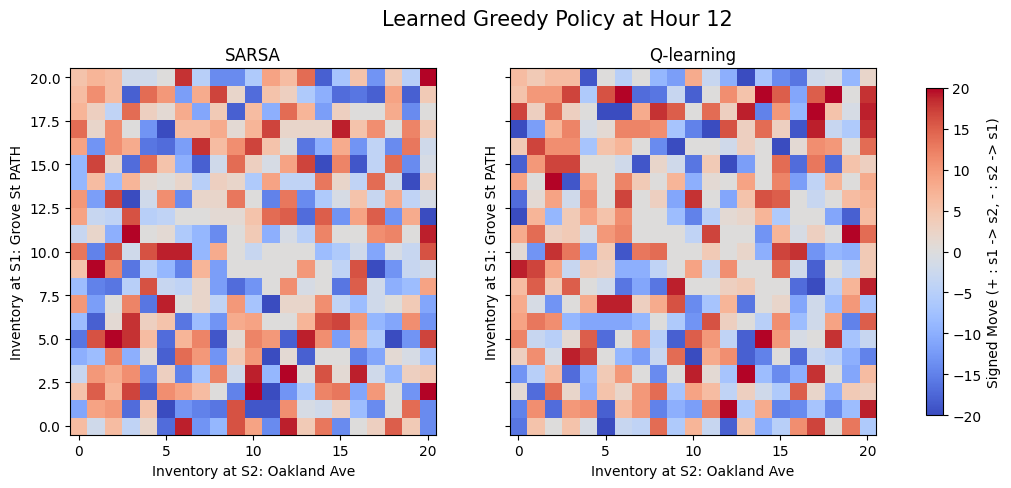

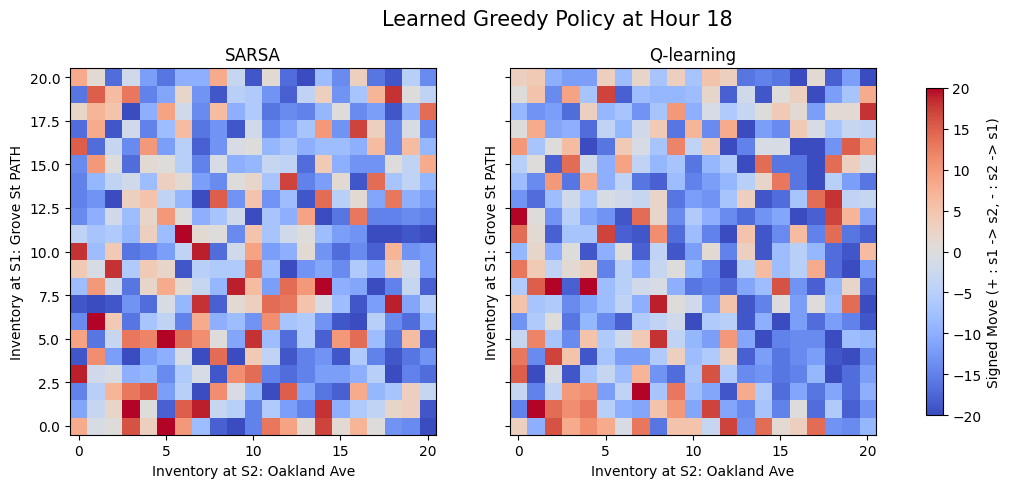

In [28]:
hours = [4, 8, 12, 18]
capacity = CitiBikeEnv().capacity

def action_to_signed_move(action):
    if action == 0:
        return 0
    if 1 <= action <= 20:
        return action
    return -(action - 20)


def policy_grid(agent, hour):
    grid = np.zeros((capacity + 1, capacity + 1))
    for b1 in range(capacity + 1):
        for b2 in range(capacity + 1):
            obs = (hour, b1, b2)
            action = agent.greedy_action(obs)
            grid[b1, b2] = action_to_signed_move(action)

    return grid


for hour in hours:
    sarsa_grid = policy_grid(sarsa_agent, hour)
    q_grid = policy_grid(q_agent, hour)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    fig.suptitle(f"Learned Greedy Policy at Hour {hour}", fontsize=15)
    im1 = axes[0].imshow(sarsa_grid,origin="lower",cmap="coolwarm",vmin=-20,vmax=20)
    axes[0].set_title("SARSA")
    axes[0].set_xlabel("Inventory at S2: Oakland Ave")
    axes[0].set_ylabel("Inventory at S1: Grove St PATH")

    im2 = axes[1].imshow(q_grid, origin="lower", cmap="coolwarm", vmin=-20,vmax=20)
    axes[1].set_title("Q-learning")
    axes[1].set_xlabel("Inventory at S2: Oakland Ave")
    axes[1].set_ylabel("Inventory at S1: Grove St PATH")
    fig.colorbar(im2,ax=axes,shrink=0.85,label="Signed Move (+ : s1 -> s2, - : s2 -> s1)")
    plt.show()